In [19]:
import pandas as pd
from pathlib import Path
import numpy as np

In [20]:
# This loads multiple seeds at once and immediately sets details in the dataframes.
def load_results(dir, name, seeds):
    trajs = []
    evals = []
    losses = []
    for seed in seeds:
        # Load from file
        trajectory = pd.read_csv(Path(dir)/ f"{name}_{seed}" / "results.csv")
        evaluation = pd.read_csv(Path(dir) / f"{name}_{seed}" / "eval_results.csv")
        loss = pd.read_csv(Path(dir) / f"{name}_{seed}" / "losses.csv")

        # Include meta-information in the dataframes
        # This is important to distinguish between different runs
        trajectory["experiment"] = name
        trajectory["seed"] = seed
        evaluation["experiment"] = name
        evaluation["seed"] = seed
        loss["experiment"] = name
        loss["seed"] = seed
        
        trajs.append(trajectory)
        evals.append(evaluation)
        losses.append(loss)
    trajectory = pd.concat(trajs, ignore_index=True)
    evals = pd.concat(evals, ignore_index=True)
    losses = pd.concat(losses, ignore_index=True)
    return trajectory, evals, losses

In [21]:
# Result directory to load
# These are pre-run results across 5 seeds, but you can edi the output dir and experiment name to your own.
# Warning: plotting is set up for more than one seed and you'll likely get an error if you only provide one seed.
output_dir = "multiple_runs"  # Example output directory
experiment_name = "mighty_experiment"  # Example experiment name
seeds = [0, 1, 2, 3, 4]  # Example seed values
trajectory, evals, losses = load_results(output_dir, experiment_name, seeds)

# Or if you want to generate random data to play around with the options:
#trajectory = pd.DataFrame(np.random.randint(0,4,size=(500, 9)), columns=["experiment", "step", "reward", "seed", "action", "state,next_state", "terminated", "truncated", "mean_episode_reward"])
#evals = pd.DataFrame(np.random.randint(0,4,size=(500, 7)), columns=["experiment", "step", "seed", "eval_episodes", "mean_eval_step_reward", "mean_eval_reward", "instance"])

/Users/theeimer/Documents/git/Mighty-DACS/mighty/mighty_utils/plotting.py:349: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  ax = sns.lineplot(
/Users/theeimer/Documents/git/Mighty-DACS/mighty/mighty_utils/plotting.py:349: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  ax = sns.lineplot(


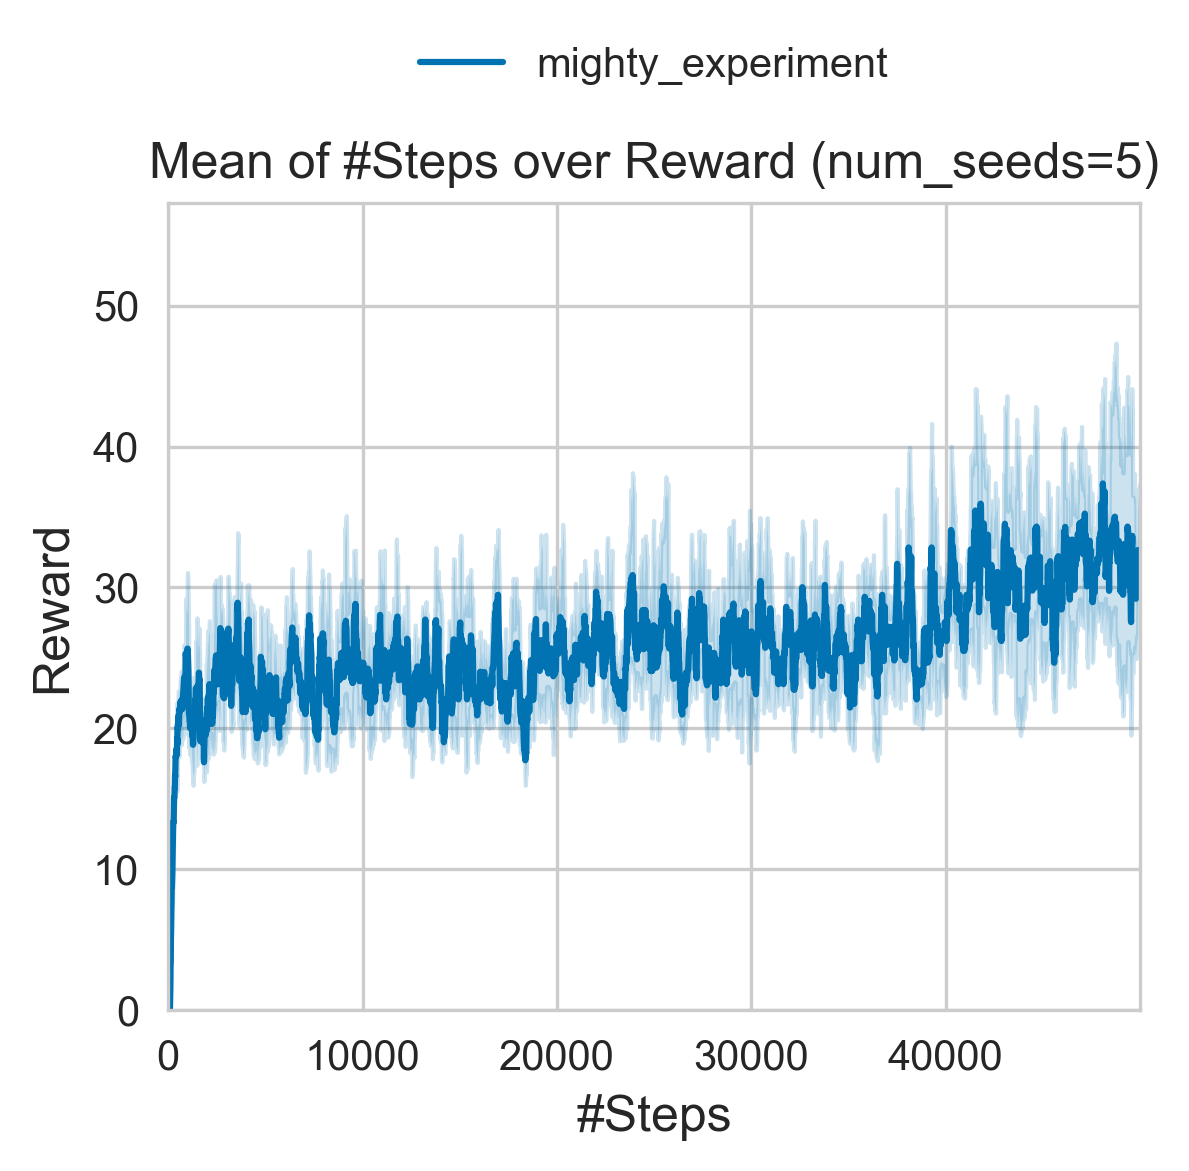

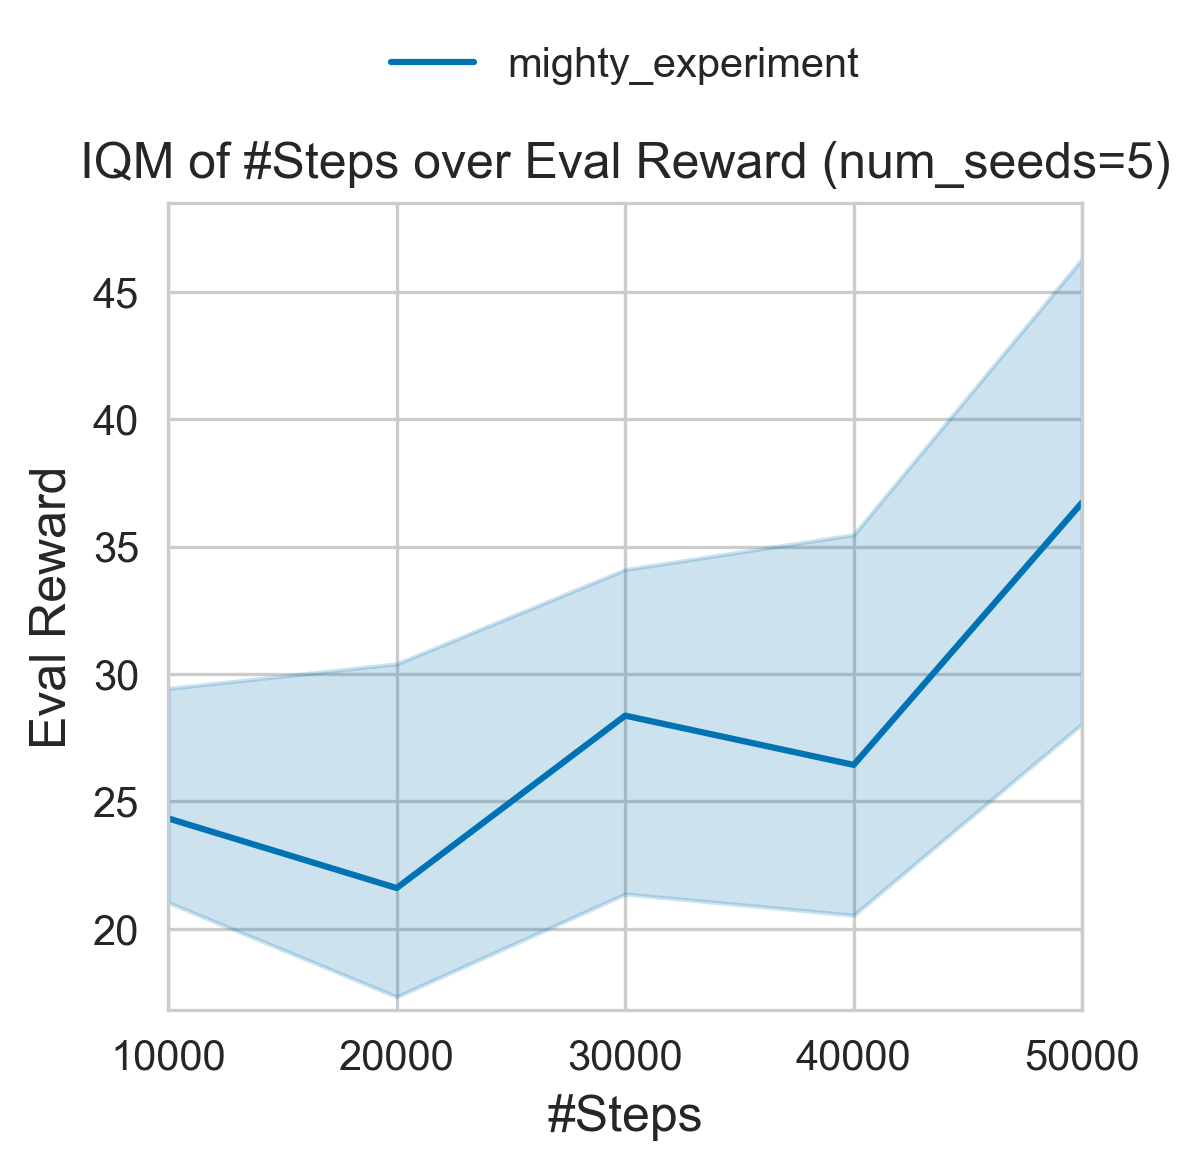

In [22]:
from mighty.mighty_utils.plotting import plot_performance_over_time
reward_plot = plot_performance_over_time(trajectory, x="step", y="mean_episode_reward", hue="experiment", aggregation="mean", logx=False, xlabel="#Steps", ylabel="Reward")
eval_plot = plot_performance_over_time(evals, x="step", y="mean_eval_reward", hue="experiment", aggregation="iqm", logx=False, xlabel="#Steps", ylabel="Eval Reward")